## Import and config

In [3]:
import os
import glob
import copy
import time
import random

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import decimate
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [4]:
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)

Using device: mps


## Data paths and file table

In [5]:
DATASET_PATH = "/Users/stijnroos/VisualStudio/DL_data/"

RAW_FOLDERS = {
    "intra_train": os.path.join(DATASET_PATH, "Intra", "train"),
    "intra_test": os.path.join(DATASET_PATH, "Intra", "test"),
    "cross_train": os.path.join(DATASET_PATH, "Cross", "train"),
    "cross_test1": os.path.join(DATASET_PATH, "Cross", "test1"),
    "cross_test2": os.path.join(DATASET_PATH, "Cross", "test2"),
    "cross_test3": os.path.join(DATASET_PATH, "Cross", "test3"),
}

def parse_filename(path):
    name = os.path.basename(path).replace(".h5", "")
    parts = name.split("_")
    subject = parts[-2]
    chunk = int(parts[-1])
    task = "_".join(parts[:-2])
    return task, subject, chunk


rows = []

for split_name, folder in RAW_FOLDERS.items():
    files = sorted(glob.glob(os.path.join(folder, "*.h5")))

    for file in files:
        task, subject, chunk = parse_filename(file)

        rows.append({
            "split": split_name,
            "file": os.path.basename(file),
            "task": task,
            "subject": subject,
            "chunk": chunk,
            "path": file,
        })

df_files = pd.DataFrame(rows)

print(df_files.shape)
df_files.head()

(152, 6)


,split,file,task,subject,chunk,path
0,intra_train,rest_105923_1.h5,rest,105923,1,/Users/stijnroos/VisualStudio/DL_data/Intra/tr...
1,intra_train,rest_105923_2.h5,rest,105923,2,/Users/stijnroos/VisualStudio/DL_data/Intra/tr...
2,intra_train,rest_105923_3.h5,rest,105923,3,/Users/stijnroos/VisualStudio/DL_data/Intra/tr...
3,intra_train,rest_105923_4.h5,rest,105923,4,/Users/stijnroos/VisualStudio/DL_data/Intra/tr...
4,intra_train,rest_105923_5.h5,rest,105923,5,/Users/stijnroos/VisualStudio/DL_data/Intra/tr...


## File readings and labels

In [6]:
def get_dataset_name(file_name_with_dir):
    filename_without_dir = file_name_with_dir.split("/")[-1]
    temp = filename_without_dir.split("_")[:-1]
    dataset_name = "_".join(temp)
    return dataset_name


def read_h5_file(filepath):
    dataset_name = get_dataset_name(filepath)

    with h5py.File(filepath, "r") as f:
        X = f[dataset_name][:]

    return X, dataset_name

TASK_TO_LABEL = {
    "rest": 0,
    "task_story_math": 1,
    "task_working_memory": 2,
    "task_motor": 3,
}

LABEL_TO_TASK = {v: k for k, v in TASK_TO_LABEL.items()}
CLASS_NAMES = [LABEL_TO_TASK[i] for i in range(len(LABEL_TO_TASK))]

print(TASK_TO_LABEL)

{'rest': 0, 'task_story_math': 1, 'task_working_memory': 2, 'task_motor': 3}


## Data preprocessing

In [7]:
def preprocess_meg(
    X,
    downsample_factor=4,
    scale=1e15,
    eps=1e-12,
):
    X = X * scale

    if downsample_factor is not None and downsample_factor > 1:
        X = decimate(X, q=downsample_factor, axis=1, zero_phase=True)

    mean = X.mean(axis=1, keepdims=True)
    std = X.std(axis=1, keepdims=True)
    X = (X - mean) / (std + eps)

    return X.astype(np.float32)


def make_windows(X, window_size=512, stride=256):
    windows = []

    for start in range(0, X.shape[1] - window_size + 1, stride):
        end = start + window_size
        windows.append(X[:, start:end])

    if len(windows) == 0:
        return np.empty((0, X.shape[0], window_size), dtype=np.float32)

    return np.stack(windows)

#### Load one split with preprocessing

In [8]:
def load_windowed_split(
    df_split,
    window_size=512,
    stride=256,
    downsample_factor=4,
):
    X_all = []
    y_all = []
    file_all = []

    for _, row in df_split.iterrows():
        X_raw, _ = read_h5_file(row["path"])

        X_processed = preprocess_meg(
            X_raw,
            downsample_factor=downsample_factor,
        )

        windows = make_windows(
            X_processed,
            window_size=window_size,
            stride=stride,
        )

        if len(windows) == 0:
            continue

        label = TASK_TO_LABEL[row["task"]]

        X_all.append(windows)
        y_all.extend([label] * len(windows))
        file_all.extend([row["file"]] * len(windows))

    X_all = np.concatenate(X_all, axis=0)
    y_all = np.array(y_all, dtype=np.int64)
    file_all = np.array(file_all)

    return X_all, y_all, file_all

#### Dataset and Dataloader

In [9]:
class MEGWindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def make_loader(X, y, batch_size=32, shuffle=False):
    dataset = MEGWindowDataset(X, y)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
    )

#### Train/Validation splits

In [10]:
def grouped_train_val_split(
    X,
    y,
    groups,
    val_size=0.2,
    random_state=42,
):
    gss = GroupShuffleSplit(
        n_splits=1,
        test_size=val_size,
        random_state=random_state,
    )

    train_idx, val_idx = next(
        gss.split(X, y, groups=groups)
    )

    return (
        X[train_idx],
        y[train_idx],
        X[val_idx],
        y[val_idx],
        groups[train_idx],
        groups[val_idx],
    )

## Model Definitions

In [11]:
class MEG1DCNN1(nn.Module):
    def __init__(self, n_channels=248, n_classes=4, dropout=0.3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(n_channels, 128, kernel_size=7, padding=3),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Conv1d(128, 256, kernel_size=5, padding=2),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


class MEG1DCNN2(nn.Module):
    def __init__(self, n_channels=248, n_classes=4, dropout=0.3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(n_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(64, 16, kernel_size=3, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


class MEG1DCNN3(nn.Module):
    def __init__(self, n_channels=248, n_classes=4, dropout=0.3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(n_channels, 16, kernel_size=7, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(16, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


class MEG1DCNN4(nn.Module):
    def __init__(self, n_channels=248, n_classes=4, dropout=0.0):
        super().__init__()

        self.conv = nn.Conv1d(n_channels, 4, kernel_size=5, padding=2)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(4, n_classes)

    def forward(self, x):
        x = torch.relu(self.conv(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

## Training and evaluation

In [12]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        preds = logits.argmax(dim=1)

        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    return total_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * X_batch.size(0)
            preds = logits.argmax(dim=1)

            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    return total_loss / total, correct / total


def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs=40,
    print_every=10,
):
    best_val_acc = -np.inf
    best_state = None

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device,
        )

        val_loss, val_acc = evaluate(
            model,
            val_loader,
            criterion,
            device,
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        if print_every is not None and epoch % print_every == 0:
            print(
                f"Epoch {epoch:03d} | "
                f"train acc {train_acc:.3f} | "
                f"val acc {val_acc:.3f}"
            )

    model.load_state_dict(best_state)

    return model, history, best_val_acc


## Prediction helper

In [13]:
def get_predictions(model, loader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)

            logits = model(X_batch)
            preds = logits.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())

    return np.array(all_labels), np.array(all_preds)

## Define experiment grid

In [14]:
MODEL_REGISTRY = {
    "MEG1DCNN1": MEG1DCNN1,
    "MEG1DCNN2": MEG1DCNN2,
    "MEG1DCNN3": MEG1DCNN3,
    "MEG1DCNN4": MEG1DCNN4,
}

EXPERIMENTS_WINDOWS = [
    # CNN2
    {
        "name": "cnn2_baseline_window",
        "model_name": "MEG1DCNN2",
        "dropout": 0.5,
        "lr": 3e-4,
        "weight_decay": 1e-3,
        "batch_size": 32,
        "epochs": 40,
        "window_size": 512,
        "stride": 256,
        "downsample_factor": 4,
    },
    {
        "name": "cnn2_short_window",
        "model_name": "MEG1DCNN2",
        "dropout": 0.5,
        "lr": 3e-4,
        "weight_decay": 1e-3,
        "batch_size": 32,
        "epochs": 40,
        "window_size": 256,
        "stride": 128,
        "downsample_factor": 4,
    },
    {
        "name": "cnn2_large_window",
        "model_name": "MEG1DCNN2",
        "dropout": 0.5,
        "lr": 3e-4,
        "weight_decay": 1e-3,
        "batch_size": 32,
        "epochs": 40,
        "window_size": 1024,
        "stride": 512,
        "downsample_factor": 4,
    },

    # CNN3
    {
        "name": "cnn3_baseline_window",
        "model_name": "MEG1DCNN3",
        "dropout": 0.5,
        "lr": 3e-4,
        "weight_decay": 1e-3,
        "batch_size": 32,
        "epochs": 40,
        "window_size": 512,
        "stride": 256,
        "downsample_factor": 4,
    },
    {
        "name": "cnn3_short_window",
        "model_name": "MEG1DCNN3",
        "dropout": 0.5,
        "lr": 3e-4,
        "weight_decay": 1e-3,
        "batch_size": 32,
        "epochs": 40,
        "window_size": 256,
        "stride": 128,
        "downsample_factor": 4,
    },
    {
        "name": "cnn3_large_window",
        "model_name": "MEG1DCNN3",
        "dropout": 0.5,
        "lr": 3e-4,
        "weight_decay": 1e-3,
        "batch_size": 32,
        "epochs": 40,
        "window_size": 1024,
        "stride": 512,
        "downsample_factor": 4,
    },

    # CNN4
    {
        "name": "cnn4_baseline_window",
        "model_name": "MEG1DCNN4",
        "dropout": 0.5,
        "lr": 3e-4,
        "weight_decay": 1e-3,
        "batch_size": 32,
        "epochs": 40,
        "window_size": 512,
        "stride": 256,
        "downsample_factor": 4,
    },
    {
        "name": "cnn4_short_window",
        "model_name": "MEG1DCNN4",
        "dropout": 0.5,
        "lr": 3e-4,
        "weight_decay": 1e-3,
        "batch_size": 32,
        "epochs": 40,
        "window_size": 256,
        "stride": 128,
        "downsample_factor": 4,
    },
    {
        "name": "cnn4_large_window",
        "model_name": "MEG1DCNN4",
        "dropout": 0.5,
        "lr": 3e-4,
        "weight_decay": 1e-3,
        "batch_size": 32,
        "epochs": 40,
        "window_size": 1024,
        "stride": 512,
        "downsample_factor": 4,
    },
]


EXPERIMENTS_LARGE = [
    # ============================================================
    # CNN2 — window size / stride
    # ============================================================
    {
        "name": "cnn2_win256_lr3e4_do05_wd1e3",
        "model_name": "MEG1DCNN2",
        "dropout": 0.5,
        "lr": 3e-4,
        "weight_decay": 1e-3,
        "batch_size": 32,
        "epochs": 80,
        "window_size": 256,
        "stride": 128,
        "downsample_factor": 4,
    },
    {
        "name": "cnn2_win512_lr3e4_do05_wd1e3",
        "model_name": "MEG1DCNN2",
        "dropout": 0.5,
        "lr": 3e-4,
        "weight_decay": 1e-3,
        "batch_size": 32,
        "epochs": 80,
        "window_size": 512,
        "stride": 256,
        "downsample_factor": 4,
    },
    {
        "name": "cnn2_win1024_lr3e4_do05_wd1e3",
        "model_name": "MEG1DCNN2",
        "dropout": 0.5,
        "lr": 3e-4,
        "weight_decay": 1e-3,
        "batch_size": 32,
        "epochs": 80,
        "window_size": 1024,
        "stride": 512,
        "downsample_factor": 4,
    },

    # CNN2 — learning rate
    {
        "name": "cnn2_win512_lr1e4_do05_wd1e3",
        "model_name": "MEG1DCNN2",
        "dropout": 0.5,
        "lr": 1e-4,
        "weight_decay": 1e-3,
        "batch_size": 32,
        "epochs": 80,
        "window_size": 512,
        "stride": 256,
        "downsample_factor": 4,
    },
    {
        "name": "cnn2_win512_lr1e3_do05_wd1e3",
        "model_name": "MEG1DCNN2",
        "dropout": 0.5,
        "lr": 1e-3,
        "weight_decay": 1e-3,
        "batch_size": 32,
        "epochs": 80,
        "window_size": 512,
        "stride": 256,
        "downsample_factor": 4,
    },

    # CNN2 — regularization
    {
        "name": "cnn2_win512_lr3e4_do03_wd1e3",
        "model_name": "MEG1DCNN2",
        "dropout": 0.3,
        "lr": 3e-4,
        "weight_decay": 1e-3,
        "batch_size": 32,
        "epochs": 80,
        "window_size": 512,
        "stride": 256,
        "downsample_factor": 4,
    },
    {
        "name": "cnn2_win512_lr3e4_do07_wd1e3",
        "model_name": "MEG1DCNN2",
        "dropout": 0.7,
        "lr": 3e-4,
        "weight_decay": 1e-3,
        "batch_size": 32,
        "epochs": 80,
        "window_size": 512,
        "stride": 256,
        "downsample_factor": 4,
    },
    {
        "name": "cnn2_win512_lr3e4_do05_wd1e4",
        "model_name": "MEG1DCNN2",
        "dropout": 0.5,
        "lr": 3e-4,
        "weight_decay": 1e-4,
        "batch_size": 32,
        "epochs": 80,
        "window_size": 512,
        "stride": 256,
        "downsample_factor": 4,
    },
    {
        "name": "cnn2_win512_lr3e4_do05_wd1e2",
        "model_name": "MEG1DCNN2",
        "dropout": 0.5,
        "lr": 3e-4,
        "weight_decay": 1e-2,
        "batch_size": 32,
        "epochs": 80,
        "window_size": 512,
        "stride": 256,
        "downsample_factor": 4,
    },

    # ============================================================
    # CNN3 — window size / stride
    # ============================================================
    {
        "name": "cnn3_win256_lr3e4_do05_wd1e3",
        "model_name": "MEG1DCNN3",
        "dropout": 0.5,
        "lr": 3e-4,
        "weight_decay": 1e-3,
        "batch_size": 32,
        "epochs": 80,
        "window_size": 256,
        "stride": 128,
        "downsample_factor": 4,
    },
    {
        "name": "cnn3_win512_lr3e4_do05_wd1e3",
        "model_name": "MEG1DCNN3",
        "dropout": 0.5,
        "lr": 3e-4,
        "weight_decay": 1e-3,
        "batch_size": 32,
        "epochs": 80,
        "window_size": 512,
        "stride": 256,
        "downsample_factor": 4,
    },
    {
        "name": "cnn3_win1024_lr3e4_do05_wd1e3",
        "model_name": "MEG1DCNN3",
        "dropout": 0.5,
        "lr": 3e-4,
        "weight_decay": 1e-3,
        "batch_size": 32,
        "epochs": 80,
        "window_size": 1024,
        "stride": 512,
        "downsample_factor": 4,
    },

    # CNN3 — learning rate
    {
        "name": "cnn3_win512_lr1e4_do05_wd1e3",
        "model_name": "MEG1DCNN3",
        "dropout": 0.5,
        "lr": 1e-4,
        "weight_decay": 1e-3,
        "batch_size": 32,
        "epochs": 80,
        "window_size": 512,
        "stride": 256,
        "downsample_factor": 4,
    },
    {
        "name": "cnn3_win512_lr1e3_do05_wd1e3",
        "model_name": "MEG1DCNN3",
        "dropout": 0.5,
        "lr": 1e-3,
        "weight_decay": 1e-3,
        "batch_size": 32,
        "epochs": 80,
        "window_size": 512,
        "stride": 256,
        "downsample_factor": 4,
    },

    # CNN3 — regularization
    {
        "name": "cnn3_win512_lr3e4_do03_wd1e3",
        "model_name": "MEG1DCNN3",
        "dropout": 0.3,
        "lr": 3e-4,
        "weight_decay": 1e-3,
        "batch_size": 32,
        "epochs": 80,
        "window_size": 512,
        "stride": 256,
        "downsample_factor": 4,
    },
    {
        "name": "cnn3_win512_lr3e4_do07_wd1e3",
        "model_name": "MEG1DCNN3",
        "dropout": 0.7,
        "lr": 3e-4,
        "weight_decay": 1e-3,
        "batch_size": 32,
        "epochs": 80,
        "window_size": 512,
        "stride": 256,
        "downsample_factor": 4,
    },
    {
        "name": "cnn3_win512_lr3e4_do05_wd1e4",
        "model_name": "MEG1DCNN3",
        "dropout": 0.5,
        "lr": 3e-4,
        "weight_decay": 1e-4,
        "batch_size": 32,
        "epochs": 80,
        "window_size": 512,
        "stride": 256,
        "downsample_factor": 4,
    },
    {
        "name": "cnn3_win512_lr3e4_do05_wd1e2",
        "model_name": "MEG1DCNN3",
        "dropout": 0.5,
        "lr": 3e-4,
        "weight_decay": 1e-2,
        "batch_size": 32,
        "epochs": 80,
        "window_size": 512,
        "stride": 256,
        "downsample_factor": 4,
    },

    # ============================================================
    # CNN4 — window size / stride
    # ============================================================
    {
        "name": "cnn4_win256_lr3e4_do05_wd1e3",
        "model_name": "MEG1DCNN4",
        "dropout": 0.5,
        "lr": 3e-4,
        "weight_decay": 1e-3,
        "batch_size": 32,
        "epochs": 80,
        "window_size": 256,
        "stride": 128,
        "downsample_factor": 4,
    },
    {
        "name": "cnn4_win512_lr3e4_do05_wd1e3",
        "model_name": "MEG1DCNN4",
        "dropout": 0.5,
        "lr": 3e-4,
        "weight_decay": 1e-3,
        "batch_size": 32,
        "epochs": 80,
        "window_size": 512,
        "stride": 256,
        "downsample_factor": 4,
    },
    {
        "name": "cnn4_win1024_lr3e4_do05_wd1e3",
        "model_name": "MEG1DCNN4",
        "dropout": 0.5,
        "lr": 3e-4,
        "weight_decay": 1e-3,
        "batch_size": 32,
        "epochs": 80,
        "window_size": 1024,
        "stride": 512,
        "downsample_factor": 4,
    },

    # CNN4 — learning rate
    {
        "name": "cnn4_win512_lr1e4_do05_wd1e3",
        "model_name": "MEG1DCNN4",
        "dropout": 0.5,
        "lr": 1e-4,
        "weight_decay": 1e-3,
        "batch_size": 32,
        "epochs": 80,
        "window_size": 512,
        "stride": 256,
        "downsample_factor": 4,
    },
    {
        "name": "cnn4_win512_lr1e3_do05_wd1e3",
        "model_name": "MEG1DCNN4",
        "dropout": 0.5,
        "lr": 1e-3,
        "weight_decay": 1e-3,
        "batch_size": 32,
        "epochs": 80,
        "window_size": 512,
        "stride": 256,
        "downsample_factor": 4,
    },

    # CNN4 — regularization
    {
        "name": "cnn4_win512_lr3e4_do03_wd1e3",
        "model_name": "MEG1DCNN4",
        "dropout": 0.3,
        "lr": 3e-4,
        "weight_decay": 1e-3,
        "batch_size": 32,
        "epochs": 80,
        "window_size": 512,
        "stride": 256,
        "downsample_factor": 4,
    },
    {
        "name": "cnn4_win512_lr3e4_do07_wd1e3",
        "model_name": "MEG1DCNN4",
        "dropout": 0.7,
        "lr": 3e-4,
        "weight_decay": 1e-3,
        "batch_size": 32,
        "epochs": 80,
        "window_size": 512,
        "stride": 256,
        "downsample_factor": 4,
    },
    {
        "name": "cnn4_win512_lr3e4_do05_wd1e4",
        "model_name": "MEG1DCNN4",
        "dropout": 0.5,
        "lr": 3e-4,
        "weight_decay": 1e-4,
        "batch_size": 32,
        "epochs": 80,
        "window_size": 512,
        "stride": 256,
        "downsample_factor": 4,
    },
    {
        "name": "cnn4_win512_lr3e4_do05_wd1e2",
        "model_name": "MEG1DCNN4",
        "dropout": 0.5,
        "lr": 3e-4,
        "weight_decay": 1e-2,
        "batch_size": 32,
        "epochs": 80,
        "window_size": 512,
        "stride": 256,
        "downsample_factor": 4,
    },
]





# test the window configurations
# EXPERIMENTS = EXPERIMENTS_WINDOWS
EXPERIMENTS = EXPERIMENTS_LARGE

## Run Intra experiment 

In [30]:
def run_intra_experiment(config):
    set_seed(SEED)

    print(f"\nRunning intra experiment: {config['name']}")

    df_intra_train = df_files[df_files["split"] == "intra_train"].reset_index(drop=True)
    df_intra_test = df_files[df_files["split"] == "intra_test"].reset_index(drop=True)

    X_intra_train, y_intra_train, files_intra_train = load_windowed_split(
        df_intra_train,
        window_size=config["window_size"],
        stride=config["stride"],
        downsample_factor=config["downsample_factor"],
    )

    X_intra_test, y_intra_test, files_intra_test = load_windowed_split(
        df_intra_test,
        window_size=config["window_size"],
        stride=config["stride"],
        downsample_factor=config["downsample_factor"],
    )

    X_train, y_train, X_val, y_val, _, _ = grouped_train_val_split(
        X_intra_train,
        y_intra_train,
        files_intra_train,
        val_size=0.2,
        random_state=SEED,
    )

    train_loader = make_loader(
        X_train,
        y_train,
        batch_size=config["batch_size"],
        shuffle=True,
    )

    val_loader = make_loader(
        X_val,
        y_val,
        batch_size=config["batch_size"],
        shuffle=False,
    )

    test_loader = make_loader(
        X_intra_test,
        y_intra_test,
        batch_size=config["batch_size"],
        shuffle=False,
    )

    model_class = MODEL_REGISTRY[config["model_name"]]

    model = model_class(
        n_channels=X_train.shape[1],
        n_classes=len(TASK_TO_LABEL),
        dropout=config["dropout"],
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )

    start_time = time.time()

    model, history, best_val_acc = train_model(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        device,
        epochs=config["epochs"],
        print_every=10,
    )

    train_time = time.time() - start_time

    test_loss, test_acc = evaluate(
        model,
        test_loader,
        criterion,
        device,
    )

    result = {
        **config,
        "setting": "intra",
        "best_val_acc": best_val_acc,
        "test_acc": test_acc,
        "test_loss": test_loss,
        "train_time": train_time,
        "history": history,
        "model": model,
        "test_loader": test_loader,
    }

    print(
        f"Finished {config['name']} | "
        f"val acc: {best_val_acc:.3f} | "
        f"test acc: {test_acc:.3f}"
    )

    return result

In [31]:
intra_results = []

for config in EXPERIMENTS:
    result = run_intra_experiment(config)
    intra_results.append(result)

intra_summary = pd.DataFrame([
    {
        k: v
        for k, v in result.items()
        if k not in ["history", "model", "test_loader"]
    }
    for result in intra_results
])

intra_summary.sort_values("test_acc", ascending=False)


Running intra experiment: cnn2_win256_lr3e4_do05_wd1e3
Epoch 010 | train acc 0.920 | val acc 0.473
Epoch 020 | train acc 0.992 | val acc 0.515
Epoch 030 | train acc 0.983 | val acc 0.555
Epoch 040 | train acc 0.982 | val acc 0.550
Epoch 050 | train acc 0.982 | val acc 0.496
Epoch 060 | train acc 0.992 | val acc 0.546
Epoch 070 | train acc 0.979 | val acc 0.546
Epoch 080 | train acc 0.988 | val acc 0.519
Finished cnn2_win256_lr3e4_do05_wd1e3 | val acc: 0.586 | test acc: 0.579

Running intra experiment: cnn2_win512_lr3e4_do05_wd1e3
Epoch 010 | train acc 0.914 | val acc 0.455
Epoch 020 | train acc 0.977 | val acc 0.537
Epoch 030 | train acc 0.990 | val acc 0.554
Epoch 040 | train acc 0.999 | val acc 0.584
Epoch 050 | train acc 1.000 | val acc 0.628
Epoch 060 | train acc 0.999 | val acc 0.641
Epoch 070 | train acc 0.998 | val acc 0.584
Epoch 080 | train acc 0.972 | val acc 0.580
Finished cnn2_win512_lr3e4_do05_wd1e3 | val acc: 0.688 | test acc: 0.568

Running intra experiment: cnn2_win102

,name,model_name,dropout,lr,weight_decay,batch_size,epochs,window_size,stride,downsample_factor,setting,best_val_acc,test_acc,test_loss,train_time
10,cnn3_win512_lr3e4_do05_wd1e3,MEG1DCNN3,0.5,0.0003,0.0010,32,80,512,256,4,intra,0.411255,0.708333,0.913092,15.656900
16,cnn3_win512_lr3e4_do05_wd1e4,MEG1DCNN3,0.5,0.0003,0.0001,32,80,512,256,4,intra,0.411255,0.700758,0.908061,14.729090
13,cnn3_win512_lr1e3_do05_wd1e3,MEG1DCNN3,0.5,0.0010,0.0010,32,80,512,256,4,intra,0.476190,0.693182,0.806925,16.029947
17,cnn3_win512_lr3e4_do05_wd1e2,MEG1DCNN3,0.5,0.0003,0.0100,32,80,512,256,4,intra,0.367965,0.689394,0.951049,15.684122
14,cnn3_win512_lr3e4_do03_wd1e3,MEG1DCNN3,0.3,0.0003,0.0010,32,80,512,256,4,intra,0.502165,0.681818,0.845151,15.069635
3,cnn2_win512_lr1e4_do05_wd1e3,MEG1DCNN2,0.5,0.0001,0.0010,32,80,512,256,4,intra,0.645022,0.678030,0.780597,22.282957
9,cnn3_win256_lr3e4_do05_wd1e3,MEG1DCNN3,0.5,0.0003,0.0010,32,80,256,128,4,intra,0.502101,0.663603,0.854133,32.801716
11,cnn3_win1024_lr3e4_do05_wd1e3,MEG1DCNN3,0.5,0.0003,0.0010,32,80,1024,512,4,intra,0.419643,0.648438,1.010891,9.310120
5,cnn2_win512_lr3e4_do03_wd1e3,MEG1DCNN2,0.3,0.0003,0.0010,32,80,512,256,4,intra,0.649351,0.625000,1.344836,22.746321
6,cnn2_win512_lr3e4_do07_wd1e3,MEG1DCNN2,0.7,0.0003,0.0010,32,80,512,256,4,intra,0.653680,0.621212,1.013716,22.507315


## Run Cross experiment

In [15]:
def run_cross_experiment(config):
    set_seed(SEED)

    print(f"\nRunning cross experiment: {config['name']}")

    df_cross_train = df_files[df_files["split"] == "cross_train"].reset_index(drop=True)
    df_cross_test1 = df_files[df_files["split"] == "cross_test1"].reset_index(drop=True)
    df_cross_test2 = df_files[df_files["split"] == "cross_test2"].reset_index(drop=True)
    df_cross_test3 = df_files[df_files["split"] == "cross_test3"].reset_index(drop=True)

    X_cross_train, y_cross_train, files_cross_train = load_windowed_split(
        df_cross_train,
        window_size=config["window_size"],
        stride=config["stride"],
        downsample_factor=config["downsample_factor"],
    )

    X_cross_test1, y_cross_test1, _ = load_windowed_split(
        df_cross_test1,
        window_size=config["window_size"],
        stride=config["stride"],
        downsample_factor=config["downsample_factor"],
    )

    X_cross_test2, y_cross_test2, _ = load_windowed_split(
        df_cross_test2,
        window_size=config["window_size"],
        stride=config["stride"],
        downsample_factor=config["downsample_factor"],
    )

    X_cross_test3, y_cross_test3, _ = load_windowed_split(
        df_cross_test3,
        window_size=config["window_size"],
        stride=config["stride"],
        downsample_factor=config["downsample_factor"],
    )

    X_train, y_train, X_val, y_val, _, _ = grouped_train_val_split(
        X_cross_train,
        y_cross_train,
        files_cross_train,
        val_size=0.2,
        random_state=SEED,
    )

    train_loader = make_loader(
        X_train,
        y_train,
        batch_size=config["batch_size"],
        shuffle=True,
    )

    val_loader = make_loader(
        X_val,
        y_val,
        batch_size=config["batch_size"],
        shuffle=False,
    )

    test1_loader = make_loader(
        X_cross_test1,
        y_cross_test1,
        batch_size=config["batch_size"],
        shuffle=False,
    )

    test2_loader = make_loader(
        X_cross_test2,
        y_cross_test2,
        batch_size=config["batch_size"],
        shuffle=False,
    )

    test3_loader = make_loader(
        X_cross_test3,
        y_cross_test3,
        batch_size=config["batch_size"],
        shuffle=False,
    )

    model_class = MODEL_REGISTRY[config["model_name"]]

    model = model_class(
        n_channels=X_train.shape[1],
        n_classes=len(TASK_TO_LABEL),
        dropout=config["dropout"],
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )

    start_time = time.time()

    model, history, best_val_acc = train_model(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        device,
        epochs=config["epochs"],
        print_every=10,
    )

    train_time = time.time() - start_time

    test1_loss, test1_acc = evaluate(model, test1_loader, criterion, device)
    test2_loss, test2_acc = evaluate(model, test2_loader, criterion, device)
    test3_loss, test3_acc = evaluate(model, test3_loader, criterion, device)

    mean_test_acc = np.mean([test1_acc, test2_acc, test3_acc])

    result = {
        **config,
        "setting": "cross",
        "best_val_acc": best_val_acc,
        "test1_acc": test1_acc,
        "test2_acc": test2_acc,
        "test3_acc": test3_acc,
        "mean_test_acc": mean_test_acc,
        "train_time": train_time,
        "history": history,
        "model": model,
        "test_loaders": [test1_loader, test2_loader, test3_loader],
    }

    print(
        f"Finished {config['name']} | "
        f"val acc: {best_val_acc:.3f} | "
        f"mean test acc: {mean_test_acc:.3f}"
    )

    return result

In [16]:
cross_results = []

for config in EXPERIMENTS:
    result = run_cross_experiment(config)
    cross_results.append(result)

cross_summary = pd.DataFrame([
    {
        k: v
        for k, v in result.items()
        if k not in ["history", "model", "test_loaders"]
    }
    for result in cross_results
])

cross_summary.sort_values("mean_test_acc", ascending=False)


Running cross experiment: cnn2_win256_lr3e4_do05_wd1e3
Epoch 010 | train acc 0.966 | val acc 0.736
Epoch 020 | train acc 0.985 | val acc 0.699
Epoch 030 | train acc 0.988 | val acc 0.727
Epoch 040 | train acc 0.988 | val acc 0.695
Epoch 050 | train acc 0.989 | val acc 0.729
Epoch 060 | train acc 0.994 | val acc 0.741
Epoch 070 | train acc 0.990 | val acc 0.693
Epoch 080 | train acc 0.996 | val acc 0.747
Finished cnn2_win256_lr3e4_do05_wd1e3 | val acc: 0.781 | mean test acc: 0.481

Running cross experiment: cnn2_win512_lr3e4_do05_wd1e3
Epoch 010 | train acc 0.941 | val acc 0.697
Epoch 020 | train acc 0.982 | val acc 0.702
Epoch 030 | train acc 0.991 | val acc 0.732
Epoch 040 | train acc 0.986 | val acc 0.739
Epoch 050 | train acc 0.997 | val acc 0.802
Epoch 060 | train acc 0.980 | val acc 0.725
Epoch 070 | train acc 0.992 | val acc 0.732
Epoch 080 | train acc 0.992 | val acc 0.748
Finished cnn2_win512_lr3e4_do05_wd1e3 | val acc: 0.802 | mean test acc: 0.511

Running cross experiment: c

,name,model_name,dropout,lr,weight_decay,batch_size,epochs,window_size,stride,downsample_factor,setting,best_val_acc,test1_acc,test2_acc,test3_acc,mean_test_acc,train_time
2,cnn2_win1024_lr3e4_do05_wd1e3,MEG1DCNN2,0.5,0.0003,0.0010,32,80,1024,512,4,cross,0.850962,0.460938,0.468750,0.644531,0.524740,29.163964
3,cnn2_win512_lr1e4_do05_wd1e3,MEG1DCNN2,0.5,0.0001,0.0010,32,80,512,256,4,cross,0.827506,0.469697,0.481061,0.623106,0.524621,44.003731
1,cnn2_win512_lr3e4_do05_wd1e3,MEG1DCNN2,0.5,0.0003,0.0010,32,80,512,256,4,cross,0.801865,0.484848,0.464015,0.585227,0.511364,43.822857
6,cnn2_win512_lr3e4_do07_wd1e3,MEG1DCNN2,0.7,0.0003,0.0010,32,80,512,256,4,cross,0.762238,0.429924,0.464015,0.617424,0.503788,43.968760
8,cnn2_win512_lr3e4_do05_wd1e2,MEG1DCNN2,0.5,0.0003,0.0100,32,80,512,256,4,cross,0.780886,0.446970,0.509470,0.554924,0.503788,42.986042
25,cnn4_win512_lr3e4_do05_wd1e4,MEG1DCNN4,0.5,0.0003,0.0001,32,80,512,256,4,cross,0.608392,0.464015,0.517045,0.524621,0.501894,24.923465
7,cnn2_win512_lr3e4_do05_wd1e4,MEG1DCNN2,0.5,0.0003,0.0001,32,80,512,256,4,cross,0.783217,0.481061,0.445076,0.577652,0.501263,42.748441
24,cnn4_win512_lr3e4_do07_wd1e3,MEG1DCNN4,0.7,0.0003,0.0010,32,80,512,256,4,cross,0.606061,0.462121,0.518939,0.517045,0.499369,24.084809
23,cnn4_win512_lr3e4_do03_wd1e3,MEG1DCNN4,0.3,0.0003,0.0010,32,80,512,256,4,cross,0.606061,0.462121,0.518939,0.517045,0.499369,21.578202
19,cnn4_win512_lr3e4_do05_wd1e3,MEG1DCNN4,0.5,0.0003,0.0010,32,80,512,256,4,cross,0.606061,0.462121,0.518939,0.517045,0.499369,23.167339


## Plotting experiments

In [17]:
def plot_histories(results, metric="val_acc"):
    plt.figure(figsize=(10, 5))

    for result in results:
        plt.plot(
            result["history"][metric],
            label=result["name"],
        )

    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.title(metric)
    plt.legend()
    plt.show()

In [18]:
# from the results, select the best 3 configurations for intra and cross, and plot their histories
intra_results = sorted(intra_results, key=lambda x: x["test_acc"], reverse=True)[:3]
cross_results = sorted(cross_results, key=lambda x: x["mean_test_acc"], reverse=True)[:3]


plot_histories(intra_results, metric="val_acc")
plot_histories(cross_results, metric="val_acc")

NameError: name 'intra_results' is not defined

In [19]:
best_intra = max(intra_results, key=lambda x: x["test_acc"])

y_true, y_pred = get_predictions(
    best_intra["model"],
    best_intra["test_loader"],
    device,
)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES,
)

disp.plot(values_format="d")
plt.title(f"Intra confusion matrix: {best_intra['name']}")
plt.xticks(rotation=45)
plt.show()

print(classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
))

NameError: name 'intra_results' is not defined

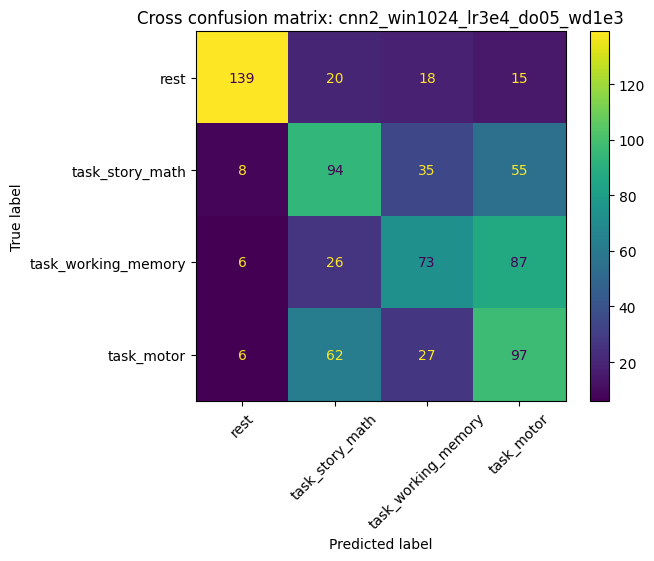

                     precision    recall  f1-score   support

               rest       0.87      0.72      0.79       192
    task_story_math       0.47      0.49      0.48       192
task_working_memory       0.48      0.38      0.42       192
         task_motor       0.38      0.51      0.43       192

           accuracy                           0.52       768
          macro avg       0.55      0.52      0.53       768
       weighted avg       0.55      0.52      0.53       768



In [20]:
best_cross = max(cross_results, key=lambda x: x["mean_test_acc"])

all_y_true = []
all_y_pred = []

for loader in best_cross["test_loaders"]:
    y_true, y_pred = get_predictions(
        best_cross["model"],
        loader,
        device,
    )

    all_y_true.append(y_true)
    all_y_pred.append(y_pred)

all_y_true = np.concatenate(all_y_true)
all_y_pred = np.concatenate(all_y_pred)

cm = confusion_matrix(all_y_true, all_y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES,
)

disp.plot(values_format="d")
plt.title(f"Cross confusion matrix: {best_cross['name']}")
plt.xticks(rotation=45)
plt.show()

print(classification_report(
    all_y_true,
    all_y_pred,
    target_names=CLASS_NAMES,
))